# Session 17 — Risk–Coverage and Selective Prediction in Medical Imaging UQ 📉

**Part 3 — Evaluation of Uncertainty**

> *Forcing a model to answer every question is not always the right design choice. A system that says "I don't know" on uncertain cases — and routes them to a specialist — is often more clinically valuable than one that answers everything with false confidence.*


<div align="center" style="margin-top: 50px;"> <img src="intro.png" width="700" /> </div>

### What this notebook covers

- The clinical motivation for **selective prediction** — why abstention is a feature, not a failure
- **Risk** and **coverage** — the two quantities that define the selective prediction tradeoff
- **Risk–coverage curves** — how error rate changes as the model retains fewer, more confident cases
- **AURC** — the scalar that summarizes the full risk-coverage tradeoff
- **Entropy-based selective prediction** for all probabilistic Part 2 methods (VI, MC Dropout, Deep Ensembles, EDL)
- **Conformal Prediction** evaluated under the same framework — varying $\alpha$ and examining coverage, set efficiency, singleton accuracy
- A **conceptual summary** of selective prediction as a general framework

---

## 🏥 Part 1 — Clinical motivation

### Why abstention matters

In most machine learning benchmarks, a model is evaluated on every test example — there is no option to abstain. But in clinical practice, the option to say *"I'm not sure — please refer this to a specialist"* is not just acceptable; it is often the right answer.

Consider a chest X-ray screening program. The AI model reviews 500 scans per day. For 80% of them, the presentation is clear — obvious consolidation, clean lung fields — and the model's prediction is reliable. For the remaining 20%, the presentation is ambiguous, the image quality is imperfect, or the case falls outside the model's training distribution. Forcing the model to make a definitive prediction on those 20% introduces unnecessary risk.

<div align="center" style="margin-top: 50px;"> <img src="section1.png" width="700" /> </div>

---

## 🎯 Part 2 — The selective prediction framework


A **selective classifier** answers only when it is confident enough, and defers the rest. The key question is not whether to defer — it is *which cases to defer* and *how many*. A good uncertainty estimate makes the model's abstention decisions clinically meaningful: it defers the cases it would likely get wrong, and handles the cases it would get right.

---

### Risk and coverage — the two fundamental quantities

**Coverage** $c$ is the fraction of cases the model answers (rather than defers):

$$c = \frac{\text{number of cases answered}}{\text{total cases}}$$

**Risk** $R(c)$ is the error rate on the answered cases at coverage level $c$:

$$R(c) = \frac{\text{errors among answered cases}}{\text{answered cases}}$$

As coverage decreases (more cases deferred), risk should decrease — because the model retains only the cases it is most confident about. A good uncertainty estimate means the deferred cases are exactly the ones the model would get wrong.

The **risk–coverage curve** traces $R(c)$ as $c$ varies from 1 (all cases answered) down to 0 (all cases deferred). The shape of this curve tells you how useful the uncertainty estimate is for clinical triage.

---

## 📊 Part 3 — AURC: the right scalar for selective prediction

The **Area Under the Risk-Coverage Curve (AURC)** summarizes the full curve in one number. Lower is better.

$$\text{AURC} = \int_0^1 R(c) \, dc$$

where $R(c)$ is the risk at coverage level $c$.

**Why AURC and not just accuracy?** Accuracy is a single point — 100% coverage. AURC measures the quality of the uncertainty over the full range of coverage levels. A method can have the same accuracy as another but a much better risk-coverage curve — meaning its uncertainty is more useful for clinical triage.

**Normalized AURC (NAURC):** divides by the random baseline AURC to give a relative score. NAURC=0 means perfect uncertainty (risk drops immediately). NAURC=1 means random uncertainty (no benefit from abstaining).

---

## 🔬 Part 4 — Entropy-based selective prediction

For each probabilistic method, we use predictive entropy as the uncertainty score. The selection rule is:

$$\text{answer if } H(x) \leq \tau, \quad \text{defer if } H(x) > \tau$$

By sweeping $\tau$ from the minimum to the maximum entropy in the test set, we trace the full risk-coverage curve. We also mark the operating points corresponding to fixed coverage targets (10%, 50%, 90%) that represent realistic clinical deployment scenarios.

Each method is analyzed in its own subsection. No cross-method ranking is made — the goal is to understand each method's selective prediction behaviour independently.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from pathlib import Path
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

np.random.seed(42)

# Load prediction results

RESULTS_DIR = "/content"

methods_cfg = {
    "VI": ("#7F77DD", f"{RESULTS_DIR}/results_vi.csv"),
    "MC_Dropout": ("#1D9E75", f"{RESULTS_DIR}/results_md.csv"),
    "Deep_Ensembles": ("#E8A838", f"{RESULTS_DIR}/results_de.csv"),
    "EDL": ("#D85A30", f"{RESULTS_DIR}/results_edl.csv"),
}

required_columns = [
    "true_label",
    "mean_pred",
    "pred_label",
]

print("Loading prediction outputs:")

dfs = {}

for method, (_, path) in methods_cfg.items():

    if not Path(path).exists():
        raise FileNotFoundError(
            f"Missing results file for {method}: {path}"
        )

    df = pd.read_csv(path)

    missing = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing:
        raise ValueError(
            f"{method} is missing required columns: {missing}"
        )

    dfs[method] = df

    print(
        f"  ✅ Loaded {method}: "
        f"{len(df)} samples"
    )

# Load conformal prediction results

cp_path = f"{RESULTS_DIR}/results_cp.csv"

if not Path(cp_path).exists():
    raise FileNotFoundError(
        f"Missing Conformal Prediction results: {cp_path}"
    )

cp_df = pd.read_csv(cp_path)

if (
    "pred_set" in cp_df.columns and
    len(cp_df) > 0 and
    isinstance(cp_df["pred_set"].iloc[0], str)
):
    cp_df["pred_set"] = cp_df["pred_set"].apply(eval)

print(
    f"  ✅ Loaded CP results: "
    f"{len(cp_df)} samples"
)

print("\nReady ✅")

In [ ]:
def risk_coverage_curve(correct, uncertainty, n_thresholds=200):
    """
    Sweep uncertainty threshold from low to high.
    At each threshold τ: retain cases with uncertainty ≤ τ.

    Returns:
        coverages  : fraction of cases retained
        risks      : error rate on retained cases
        thresholds : the threshold values swept
    """
    thresholds = np.linspace(uncertainty.min(),
                              uncertainty.max(), n_thresholds)
    coverages, risks = [], []
    for tau in thresholds:
        retained = uncertainty <= tau
        cov = retained.mean()
        risk = 1 - correct[retained].mean() if retained.sum() > 0 else 0.0
        coverages.append(cov)
        risks.append(risk)
    return np.array(coverages), np.array(risks), thresholds


def compute_aurc(coverages, risks):
    """Area Under Risk-Coverage Curve (lower = better)."""
    idx  = np.argsort(coverages)
    return np.trapz(risks[idx], coverages[idx])


def random_baseline_aurc(correct):
    """AURC if uncertainty were random — the baseline to beat."""
    return (1 - correct.mean()) * 0.5


def risk_at_coverage(coverages, risks, target_cov):
    """Risk at a specific coverage target."""
    idx = np.argmin(np.abs(coverages - target_cov))
    return risks[idx]


print('Risk-coverage functions defined ✅')

In [ ]:
def analyse_method(name, df, color, coverage_targets=[0.10, 0.50, 0.90]):
    """
    Selective prediction analysis:
    - Risk–coverage curve (formal selective prediction only)
    - No entropy-based grouping or statistical analysis
    """
    correct   = df['correct'].values
    entropy   = df['predictive_entropy'].values
    overall_risk = 1 - correct.mean()

    covs, risks, taus = risk_coverage_curve(correct, entropy)
    aurc      = compute_aurc(covs, risks)
    rand_aurc = random_baseline_aurc(correct)
    naurc     = aurc / rand_aurc if rand_aurc > 0 else 1.0

    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    fig.suptitle(f'{name} — Selective Prediction Analysis', fontsize=13)


    ax.plot(covs, risks, color=color, linewidth=2.5,
            label=f'Risk-coverage (AURC={aurc:.4f})')

    ax.axhline(overall_risk, color='black', linewidth=1.5,
               linestyle='--', alpha=0.5,
               label=f'Overall risk = {overall_risk:.3f}')

    ax.fill_between(covs, risks, overall_risk,
                    where=(risks < overall_risk),
                    alpha=0.15, color=color)

    op_risks = {}
    for cov_target, marker, ls in zip(
            coverage_targets, ['o','s','D'], ['--','-.',':']):
        r = risk_at_coverage(covs, risks, cov_target)
        op_risks[cov_target] = r

        ax.scatter(cov_target, r, s=100, color=color,
                   marker=marker, zorder=5)

        ax.annotate(f'{cov_target:.0%} cov\n→ {r:.3f} risk',
                    xy=(cov_target, r),
                    xytext=(cov_target - 0.18, r + 0.02),
                    fontsize=8,
                    arrowprops=dict(arrowstyle='->', lw=0.8))

    ax.set_xlabel('Coverage', fontsize=10)
    ax.set_ylabel('Risk (error rate on retained)', fontsize=10)
    ax.set_title('Risk–Coverage curve', fontsize=11)
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()

    print(f'\n{name} — Selective Prediction Summary')
    print(f'Overall accuracy : {correct.mean():.4f}')
    print(f'Overall risk     : {overall_risk:.4f}')
    print(f'AURC             : {aurc:.4f}')
    print(f'NAURC            : {naurc:.4f}')

    return {
        'name': name,
        'color': color,
        'covs': covs,
        'risks': risks,
        'aurc': aurc,
        'naurc': naurc,
        'overall_risk': overall_risk,
        'op_risks': op_risks
    }

### 🔵 4.1 Variational Inference

/tmp/ipykernel_880/3625097315.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(risks[idx], coverages[idx])


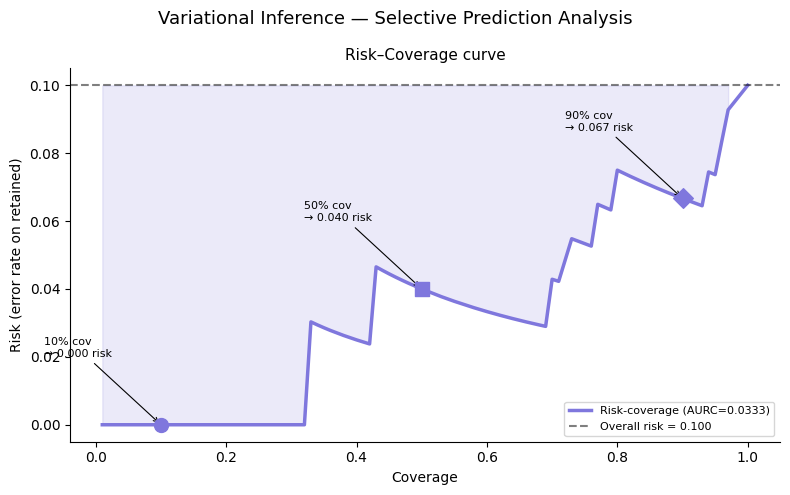


Variational Inference — Selective Prediction Summary
Overall accuracy : 0.9000
Overall risk     : 0.1000
AURC             : 0.0333
NAURC            : 0.6666


In [ ]:
results_rc = {}
results_rc['VI'] = analyse_method('Variational Inference',
                                  dfs['VI'], '#7F77DD')

---

### 🟢 4.2 Monte Carlo Dropout

/tmp/ipykernel_880/3625097315.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(risks[idx], coverages[idx])


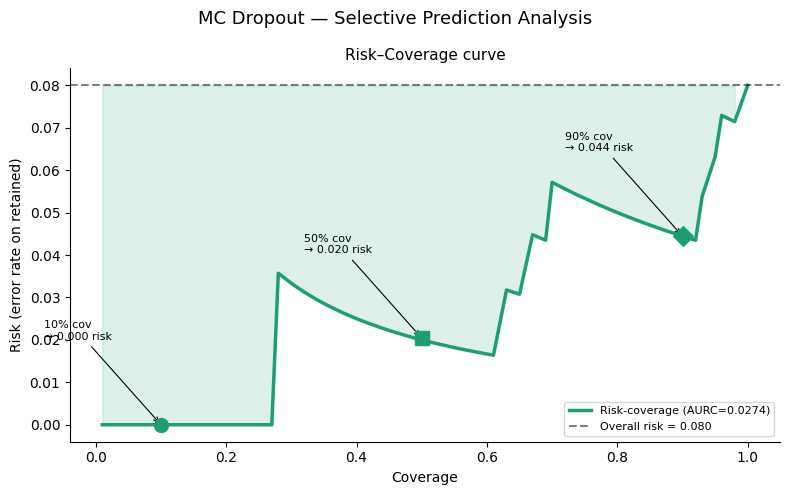


MC Dropout — Selective Prediction Summary
Overall accuracy : 0.9200
Overall risk     : 0.0800
AURC             : 0.0274
NAURC            : 0.6860


In [ ]:
results_rc['MC_Dropout'] = analyse_method('MC Dropout',
                                           dfs['MC_Dropout'], '#1D9E75')

---

### 🟡 4.3 Deep Ensembles

/tmp/ipykernel_880/3625097315.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(risks[idx], coverages[idx])


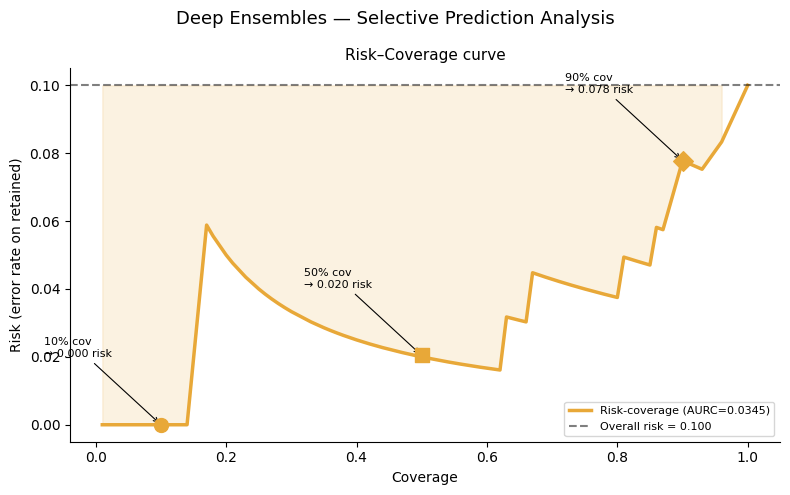


Deep Ensembles — Selective Prediction Summary
Overall accuracy : 0.9000
Overall risk     : 0.1000
AURC             : 0.0345
NAURC            : 0.6906


In [ ]:
results_rc['Deep_Ensembles'] = analyse_method('Deep Ensembles',
                                               dfs['Deep_Ensembles'], '#E8A838')

---

### 🔴 4.4 Evidential Deep Learning

/tmp/ipykernel_880/3625097315.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(risks[idx], coverages[idx])


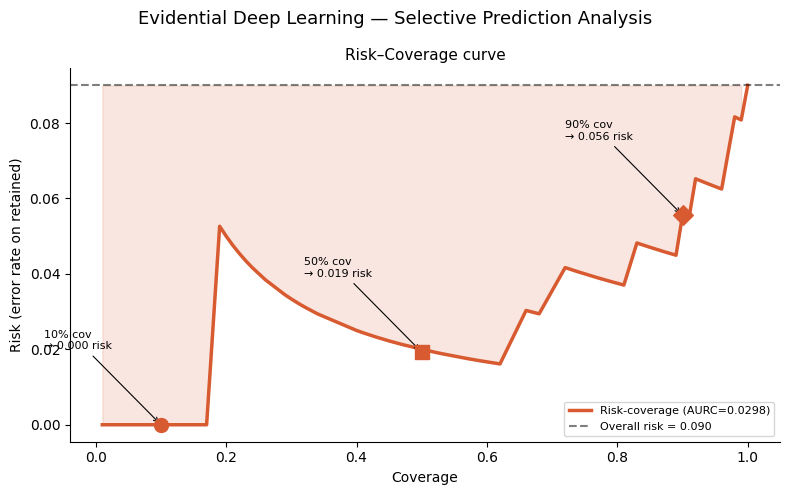


Evidential Deep Learning — Selective Prediction Summary
Overall accuracy : 0.9100
Overall risk     : 0.0900
AURC             : 0.0298
NAURC            : 0.6625


In [ ]:
results_rc['EDL'] = analyse_method('Evidential Deep Learning',
                                    dfs['EDL'], '#D85A30')

---

## 📊 Part 5 — All risk–coverage curves together

The four curves shown together reveal the shape of each method's risk-coverage tradeoff. No ranking is implied — the curves are shown together for visual reference, not for winner-picking.

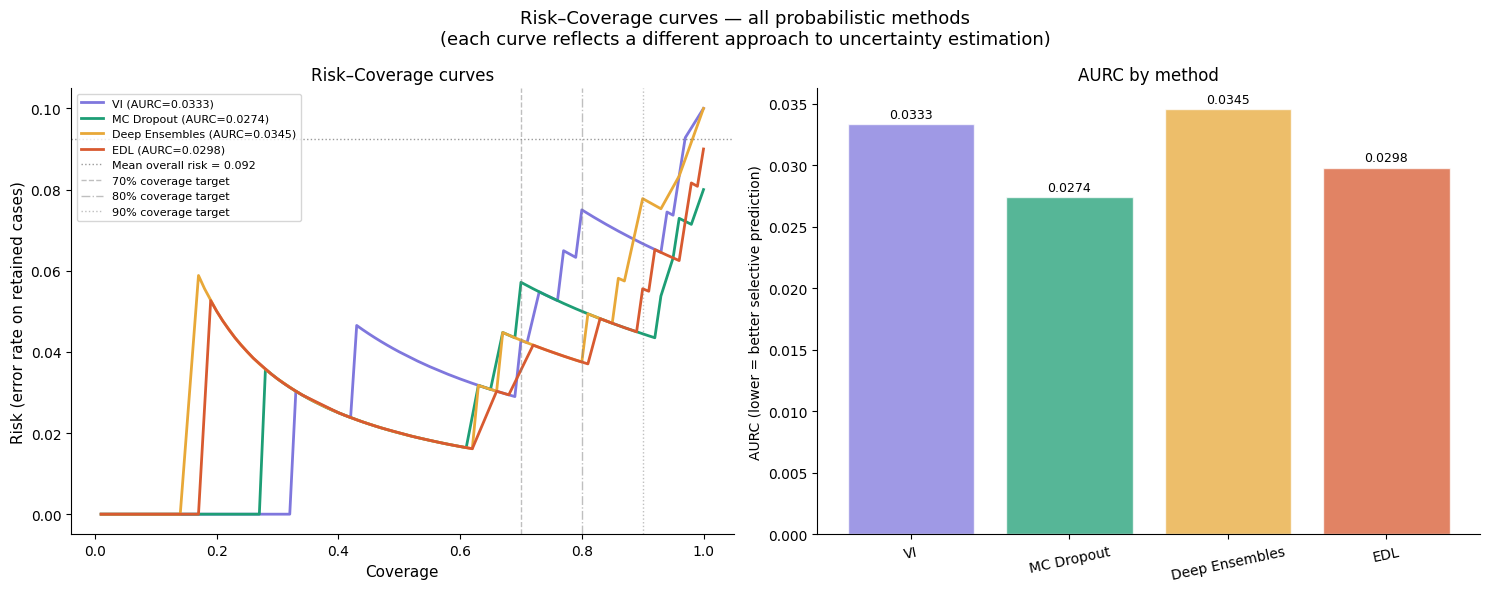

Selective prediction summary (all methods):
Method               |     AURC |    NAURC |   Risk@70% |   Risk@80% |   Risk@90%
----------------------------------------------------------------------------------------
VI                   |   0.0333 |   0.6666 |     0.0000 |     0.0400 |     0.0667 | 
MC Dropout           |   0.0274 |   0.6860 |     0.0000 |     0.0204 |     0.0444 | 
Deep Ensembles       |   0.0345 |   0.6906 |     0.0000 |     0.0204 |     0.0778 | 
EDL                  |   0.0298 |   0.6625 |     0.0000 |     0.0192 |     0.0556 | 


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Risk–Coverage curves — all probabilistic methods\n'
             '(each curve reflects a different approach to uncertainty estimation)',
             fontsize=13)

# All curves
for name, res in results_rc.items():
    axes[0].plot(res['covs'], res['risks'],
                 color=res['color'], linewidth=2.0,
                 label=f"{name.replace('_',' ')} (AURC={res['aurc']:.4f})")

# Random baseline
mean_risk = np.mean([r['overall_risk'] for r in results_rc.values()])
axes[0].axhline(mean_risk, color='black', linewidth=1,
                linestyle=':', alpha=0.4,
                label=f'Mean overall risk = {mean_risk:.3f}')

# Operating point lines
for cov, ls in [(0.70,'--'), (0.80,'-.'), (0.90,':')]:
    axes[0].axvline(cov, color='grey', linewidth=1,
                    linestyle=ls, alpha=0.5,
                    label=f'{cov:.0%} coverage target')

axes[0].set_xlabel('Coverage', fontsize=11)
axes[0].set_ylabel('Risk (error rate on retained cases)', fontsize=11)
axes[0].set_title('Risk–Coverage curves', fontsize=12)
axes[0].legend(fontsize=8)
axes[0].spines[['top','right']].set_visible(False)

# AURC bar chart
names  = [n.replace('_',' ') for n in results_rc]
aurcs  = [r['aurc'] for r in results_rc.values()]
colors = [r['color'] for r in results_rc.values()]
bars   = axes[1].bar(names, aurcs, color=colors, alpha=0.75, edgecolor='white')
axes[1].set_ylabel('AURC (lower = better selective prediction)', fontsize=10)
axes[1].set_title('AURC by method', fontsize=12)
axes[1].tick_params(axis='x', rotation=12)
axes[1].spines[['top','right']].set_visible(False)
for bar, v in zip(bars, aurcs):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 v + 0.0005, f'{v:.4f}',
                 ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Summary table
print('Selective prediction summary (all methods):')
print(f'{"Method":20s} | {"AURC":>8} | {"NAURC":>8} | '
      f'{"Risk@70%":>10} | {"Risk@80%":>10} | {"Risk@90%":>10}')
print('-' * 88)
for name, res in results_rc.items():
    print(f'{name.replace("_"," "):20s} | {res["aurc"]:8.4f} | '
          f'{res["naurc"]:8.4f} | '
          f'{res["op_risks"][0.10]:10.4f} | '
          f'{res["op_risks"][0.50]:10.4f} | '
          f'{res["op_risks"][0.90]:10.4f} | ')

---

## 🎯 Part 6 — Fixed operating points and clinical thresholds

Sweeping the full risk–coverage curve is useful for evaluation, but in real deployment we must choose a **single operating point**: a decision rule that defines which cases are handled by the AI and which are deferred to a radiologist.

In this work, we focus on two complementary ways of defining such clinical thresholds.


### 📊 Coverage-based clinical operating points

Coverage-based selection directly controls how many cases the model is allowed to handle. Instead of using a continuous curve, we fix a target retention rate and derive a threshold that enforces it.

We evaluate three clinically meaningful operating points:

* **90% coverage:** the AI handles most cases autonomously, referring only the most uncertain 10%. This prioritizes throughput and scalability.

* **50% coverage:** a balanced setting where the workload is shared equally between AI and radiologist, suitable for decision-support scenarios.

* **10% coverage:** a highly conservative regime where only the most confident predictions are retained, maximizing reliability on handled cases while heavily relying on referral.

These points provide a direct way to translate uncertainty estimates into **workload-controlled clinical policies**.

### 🧠 Alternative: data-driven uncertainty thresholds

Beyond predefined coverage levels, another strategy is to derive thresholds directly from the uncertainty distribution.

In our implementation notebooks, we use a **clustering-based approach**, where predictive uncertainty (e.g., entropy) is grouped into two clusters corresponding to “certain” and “uncertain” predictions. The decision boundary between these clusters is then used as a threshold for clinical triage.

This approach does not require specifying a target coverage in advance. Instead, it allows the data to determine the separation between easy and difficult cases.


### 🔬 Key interpretation

Both approaches define a single clinical decision boundary, but differ in their philosophy:

* **Coverage-based thresholding:**

  “We choose how many cases the AI should handle.”

* **Clustering-based thresholding:**

  “We let the data define what is easy vs difficult.”


Together, they represent two complementary strategies for translating uncertainty into clinical decision-making.


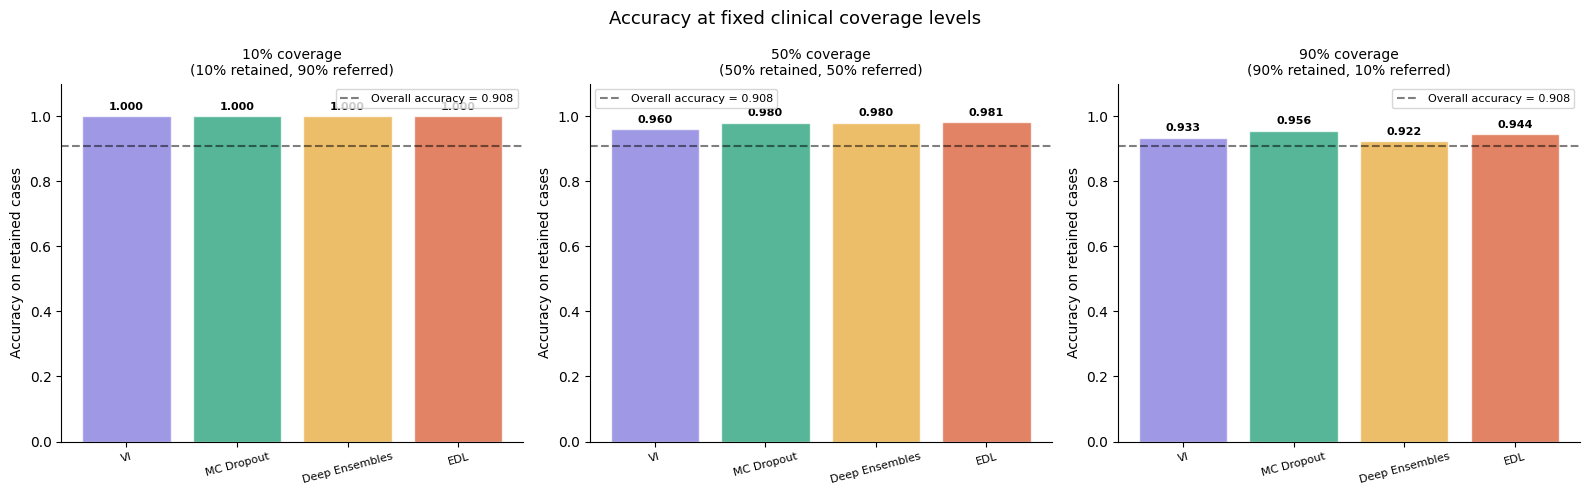

In [ ]:
coverage_targets = [0.10, 0.50, 0.90]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'Accuracy at fixed clinical coverage levels',
    fontsize=13
)

for ax, cov_target in zip(axes, coverage_targets):

    method_names = [n.replace('_', ' ') for n in results_rc]
    risks_at_cov = [res['op_risks'][cov_target] for res in results_rc.values()]
    colors = [res['color'] for res in results_rc.values()]

    accuracies = [1 - r for r in risks_at_cov]

    bars = ax.bar(
        method_names,
        accuracies,
        color=colors,
        alpha=0.75,
        edgecolor='white'
    )

    overall_accs = [dfs[n]['correct'].mean() for n in results_rc]
    mean_overall = np.mean(overall_accs)

    ax.axhline(
        mean_overall,
        color='black',
        linewidth=1.5,
        linestyle='--',
        alpha=0.5,
        label=f'Overall accuracy = {mean_overall:.3f}'
    )

    ax.set_ylim(0, 1.1)
    ax.set_title(
        f'{cov_target:.0%} coverage\n'
        f'({cov_target:.0%} retained, {1-cov_target:.0%} referred)',
        fontsize=10
    )

    ax.set_ylabel('Accuracy on retained cases')
    ax.tick_params(axis='x', rotation=15, labelsize=8)
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

    for bar, acc in zip(bars, accuracies):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            acc + 0.02,
            f'{acc:.3f}',
            ha='center',
            fontsize=8,
            fontweight='bold'
        )

plt.tight_layout()
plt.show()

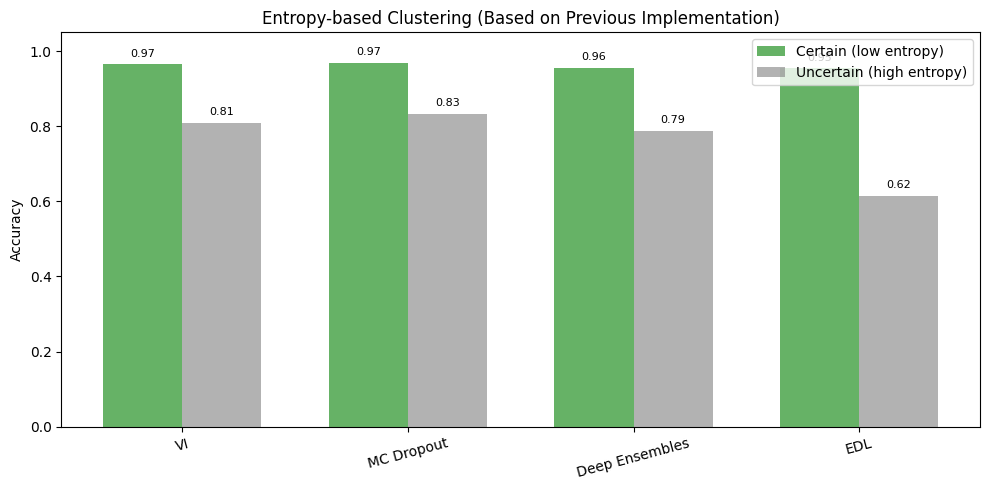

In [ ]:
ENTROPY_THRESHOLDS = {
    'VI': 0.3612,
    'MC_Dropout': 0.3782,
    'Deep_Ensembles': 0.3920,
    'EDL': 0.3262
}

method_names = [n.replace('_', ' ') for n in results_rc]
colors = [res['color'] for res in results_rc.values()]

cert_accs = []
unc_accs = []

for name in results_rc:

    df = dfs[name]
    entropy = df['predictive_entropy'].values
    correct = df['correct'].values

    thr = ENTROPY_THRESHOLDS[name]

    cert_mask = entropy <= thr
    unc_mask = entropy > thr

    cert_accs.append(correct[cert_mask].mean())
    unc_accs.append(correct[unc_mask].mean())

x = np.arange(len(method_names))
width = 0.35

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

bars1 = ax.bar(x - width/2, cert_accs, width,
               label='Certain (low entropy)',
               color='green', alpha=0.6)

bars2 = ax.bar(x + width/2, unc_accs, width,
               label='Uncertain (high entropy)',
               color='gray', alpha=0.6)

ax.set_xticks(x)
ax.set_xticklabels(method_names, rotation=15)
ax.set_ylim(0, 1.05)

ax.set_ylabel('Accuracy')
ax.set_title('Entropy-based Clustering (Based on Previous Implementation)')
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{bar.get_height():.2f}',
            ha='center',
            fontsize=8
        )

plt.tight_layout()
plt.show()

---

## 🟣 Part 7 — Conformal Prediction under the selective prediction framework

Conformal Prediction operates differently from the probabilistic methods. There is no entropy score to threshold. Instead:

- The parameter $\alpha$ controls the target miscoverage rate
- A **larger $\alpha$** (e.g. 0.30) → smaller threshold $\hat{\tau}$ → smaller prediction sets → more singletons
- A **smaller $\alpha$** (e.g. 0.05) → larger threshold $\hat{\tau}$ → larger prediction sets → fewer singletons

In the selective prediction framework:
- **Singleton set ($|C|=1$):** the model makes a definitive prediction — analogous to "retained"
- **Full set ($|C|=2$):** the model cannot distinguish — analogous to "deferred"

We sweep $\alpha$ from 0.01 to 0.10 and track:
- Empirical coverage (does the guarantee hold?)
- Average set size
- Singleton rate (fraction of definitive predictions)
- Accuracy restricted to singleton predictions

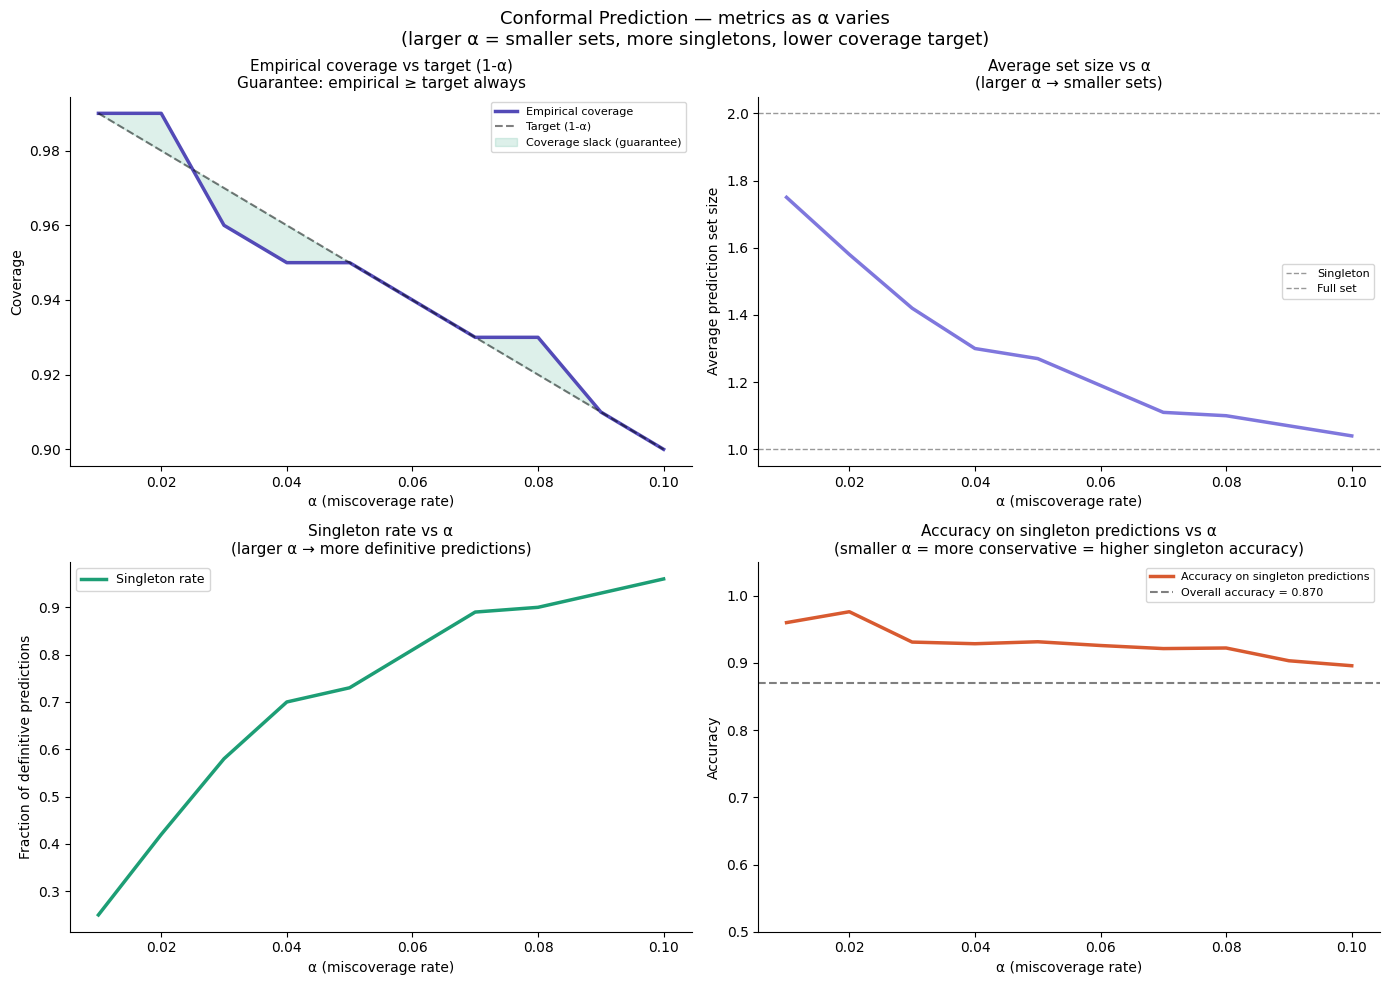

CP metrics at selected α values:
     α |   Target cov |   Emp. cov |   Avg size |  Singleton % |  Singleton acc
---------------------------------------------------------------------------
  0.01 |         0.99 |     0.9900 |     1.7500 |       0.250 |         0.9600
  0.01 |         0.99 |     0.9900 |     1.7500 |       0.250 |         0.9600
  0.03 |         0.97 |     0.9600 |     1.4200 |       0.580 |         0.9310
  0.05 |         0.95 |     0.9500 |     1.2700 |       0.730 |         0.9315
  0.07 |         0.93 |     0.9300 |     1.1100 |       0.890 |         0.9213
  0.09 |         0.91 |     0.9100 |     1.0700 |       0.930 |         0.9032
  0.10 |         0.90 |     0.9000 |     1.0400 |       0.960 |         0.8958


In [ ]:
# Reconstruct calibration scores from CP results
# We use the nonconf_score column as proxy calibration scores
nc_scores     = cp_df['nonconf_score'].values
test_labels   = cp_df['true_label'].values
test_probs    = cp_df['mean_pred'].values
test_correct  = cp_df['correct'].values

cal_nc_scores = np.load("cal_scores.npy")

alpha_values  = np.linspace(0.01, 0.10, 10)
emp_covs, avg_sizes, sing_rates, sing_accs, taus_alpha = [], [], [], [], []

for alpha in alpha_values:
    n_c  = len(cal_nc_scores)
    lvl  = np.ceil((n_c + 1) * (1 - alpha)) / n_c
    tau  = np.quantile(cal_nc_scores, min(lvl, 1.0))
    taus_alpha.append(tau)

    pred_sets, covered_list, sizes = [], [], []
    for i in range(len(test_labels)):
        p   = test_probs[i]
        nc0 = p           # nonconformity for class 0: 1 - p(0) = p(1) = p
        nc1 = 1 - p       # nonconformity for class 1: 1 - p(1) = p(0) = 1-p
        ps  = ([0] if nc0 <= tau else []) + ([1] if nc1 <= tau else [])
        if not ps: ps = [0, 1]
        pred_sets.append(ps)
        covered_list.append(int(test_labels[i] in ps))
        sizes.append(len(ps))

    sizes         = np.array(sizes)
    covered_arr   = np.array(covered_list)
    singleton_mask = sizes == 1

    emp_cov  = covered_arr.mean()
    avg_size = sizes.mean()
    sing_rate = singleton_mask.mean()

    if singleton_mask.sum() > 0:
        # Accuracy on singleton predictions
        singleton_preds  = np.array([
            ps[0] for ps, s in zip(pred_sets, sizes) if s == 1
        ])
        singleton_labels = test_labels[singleton_mask]
        sing_acc = (singleton_preds == singleton_labels).mean()
    else:
        sing_acc = np.nan

    emp_covs.append(emp_cov)
    avg_sizes.append(avg_size)
    sing_rates.append(sing_rate)
    sing_accs.append(sing_acc)

emp_covs   = np.array(emp_covs)
avg_sizes  = np.array(avg_sizes)
sing_rates = np.array(sing_rates)
sing_accs  = np.array(sing_accs)

fig, axes  = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Conformal Prediction — metrics as α varies\n'
             '(larger α = smaller sets, more singletons, lower coverage target)',
             fontsize=13)

# Coverage
axes[0,0].plot(alpha_values, emp_covs, color='#534AB7', linewidth=2.5,
               label='Empirical coverage')
axes[0,0].plot(alpha_values, 1-alpha_values, 'k--', linewidth=1.5,
               alpha=0.5, label='Target (1-α)')
axes[0,0].fill_between(alpha_values, 1-alpha_values, emp_covs,
                        alpha=0.15, color='#1D9E75',
                        label='Coverage slack (guarantee)')
axes[0,0].set_xlabel('α (miscoverage rate)', fontsize=10)
axes[0,0].set_ylabel('Coverage', fontsize=10)
axes[0,0].set_title('Empirical coverage vs target (1-α)\n'
                     'Guarantee: empirical ≥ target always', fontsize=11)
axes[0,0].legend(fontsize=8)
axes[0,0].spines[['top','right']].set_visible(False)

# Average set size
axes[0,1].plot(alpha_values, avg_sizes, color='#7F77DD', linewidth=2.5)
axes[0,1].axhline(1, color='black', linewidth=1, linestyle='--',
                   alpha=0.4, label='Singleton')
axes[0,1].axhline(2, color='black', linewidth=1, linestyle='--',
                   alpha=0.4, label='Full set')
axes[0,1].set_xlabel('α (miscoverage rate)', fontsize=10)
axes[0,1].set_ylabel('Average prediction set size', fontsize=10)
axes[0,1].set_title('Average set size vs α\n'
                     '(larger α → smaller sets)', fontsize=11)
axes[0,1].legend(fontsize=8)
axes[0,1].spines[['top','right']].set_visible(False)

# Singleton rate
axes[1,0].plot(alpha_values, sing_rates, color='#1D9E75', linewidth=2.5,
               label='Singleton rate')
axes[1,0].set_xlabel('α (miscoverage rate)', fontsize=10)
axes[1,0].set_ylabel('Fraction of definitive predictions', fontsize=10)
axes[1,0].set_title('Singleton rate vs α\n'
                     '(larger α → more definitive predictions)',
                     fontsize=11)
axes[1,0].legend(fontsize=9)
axes[1,0].spines[['top','right']].set_visible(False)

# Singleton accuracy
valid = ~np.isnan(sing_accs)
axes[1,1].plot(alpha_values[valid], sing_accs[valid],
               color='#D85A30', linewidth=2.5,
               label='Accuracy on singleton predictions')
overall_acc_cp = cp_df['correct'].mean()
axes[1,1].axhline(overall_acc_cp, color='black', linewidth=1.5,
                   linestyle='--', alpha=0.5,
                   label=f'Overall accuracy = {overall_acc_cp:.3f}')
axes[1,1].set_xlabel('α (miscoverage rate)', fontsize=10)
axes[1,1].set_ylabel('Accuracy', fontsize=10)
axes[1,1].set_title('Accuracy on singleton predictions vs α\n'
                     '(smaller α = more conservative = higher singleton accuracy)',
                     fontsize=11)
axes[1,1].legend(fontsize=8)
axes[1,1].set_ylim(0.5, 1.05)
axes[1,1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

# Print table at key alpha values
print('CP metrics at selected α values:')
print(f'{"α":>6} | {"Target cov":>12} | {"Emp. cov":>10} | '
      f'{"Avg size":>10} | {"Singleton %":>12} | {"Singleton acc":>14}')
print('-' * 75)
for a_target in [0, 0.01, 0.03, 0.05, 0.07, 0.09, 0.10]:
    idx = np.argmin(np.abs(alpha_values - a_target))
    print(f'{alpha_values[idx]:6.2f} | {1-alpha_values[idx]:12.2f} | '
          f'{emp_covs[idx]:10.4f} | {avg_sizes[idx]:10.4f} | '
          f'{sing_rates[idx]:11.3f} | '
          f'{sing_accs[idx]:14.4f}' if not np.isnan(sing_accs[idx])
          else f'{alpha_values[idx]:6.2f} | {1-alpha_values[idx]:12.2f} | '
          f'{emp_covs[idx]:10.4f} | {avg_sizes[idx]:10.4f} | '
          f'{sing_rates[idx]:11.3f} |           N/A')

---

## 📚 Recommended reading

These are the most important papers on risk-coverage, selective prediction, and reject-option learning. They explain where the idea came from, how it works in deep learning, and how modern variants improve the tradeoff between answering and deferring. 🗺️

**[Selective Classification for Deep Neural Networks](https://arxiv.org/abs/1705.08500)**  
*Geifman & El-Yaniv, 2017*  
A foundational deep-learning paper for selective prediction. It shows how to wrap a trained classifier with a reject option and optimize for a target risk level while controlling coverage.

**[Bias-Reduced Uncertainty Estimation for Deep Neural Classifiers](https://arxiv.org/abs/1805.08206)**  
*Geifman, Uziel & El-Yaniv, 2018*  
An important follow-up that explains why naive uncertainty scores can be biased and proposes a better estimate for highly confident predictions. Useful for understanding why selective prediction is harder than just thresholding entropy.

**[SelectiveNet: A Deep Neural Network with an Integrated Reject Option](https://arxiv.org/abs/1901.09192)**  
*Geifman & El-Yaniv, 2019*  
A major modern extension that trains the reject option end-to-end instead of bolting it on after the fact. One of the most cited deep selective classification papers.

**[A Survey of Selective Classification](https://arxiv.org/abs/2405.11533)**  
*Goren, Galil & El-Yaniv, 2024*  
A recent overview of the field, including hierarchical selective classification and modern evaluation ideas. Good for seeing how the area has evolved beyond the original binary reject setting.


---

## ✅ Session summary

| Step                | What we did                                                                        |
| ------------------- | ---------------------------------------------------------------------------------- |
| 🏥 Clinical idea    | Framed AI as a **selective system that can defer uncertain cases** to radiologists |
| ⚖️ Core setup       | Defined **coverage (how many answered)** and **risk (error on answered set)**      |
| 📉 Main tool        | Built **risk–coverage curves** to study performance across abstention levels       |
| 📏 Key metric       | Used **AURC / NAURC** to summarize uncertainty behavior in one number              |
| 🧠 Uncertainty      | Used **predictive entropy** to decide which cases are answered vs deferred         |
| 🔵 Methods          | Applied VI, MC Dropout, Deep Ensembles, and EDL under the same framework           |
| 🚦 Operating points | Evaluated fixed **10%, 50%, 90% coverage** clinical settings                       |
| 📊 Analysis view    | Visualized curves and AURC to show selective behavior across methods               |
| 🟣 Conformal        | Added CP as a **set-based method with formal coverage guarantees (α control)**     |
---

> **➡️ Next: Session 18: Out-of-Distribution (OOD) Detection**  
> Session 18 asks what happens when the model meets genuinely unfamiliar data. We move from selective answering to out-of-distribution detection, where the key question is whether the system can recognize when it is outside its validated territory and hand the case off instead of pretending to know.